---
---

# **Employee Performance Level: Modeling and Prediction**  
*Authored by Sean Kafka Adhyaksa*

---
---

This notebook continues the employee performance project into the predictive stage. The earlier analysis focused on understanding which employee and workplace conditions appear most often around different `PerformanceScore` outcomes. The next step is to translate those findings into a structured classification workflow.

The objective here is not only to pursue the highest score possible. The modeling process also needs to remain interpretable, consistent, and responsible for an HR setting. For that reason, this notebook focuses on feature readiness, preprocessing design, class imbalance handling, baseline comparison, and careful evaluation before moving toward deployment.

**Key Findings**
1. The baseline comparison showed that **Gradient Boosting** produced the strongest overall result among 4 other compared models, making it the most suitable candidate for further tuning.

2. The preprocessing design required careful revision. `SMOTENC` was positioned between numerical scaling and categorical encoding so that imbalance handling could operate on the correct feature structure.

3. Scaling choice also affected model quality. `RobustScaler` was initially considered because several numerical features showed skewed distributions and different value ranges. However, `StandardScaler` produced stronger baseline performance in the final pipeline and was therefore retained.

4. After hyperparameter tuning, the final Gradient Boosting model achieved a higher **F1-macro** result and showed solid predictive performance on the test set. The model performed especially well on `Fully Meets`, while `Needs Improvement` and `PIP` were also captured reasonably well despite their small class sizes.

**Recommendations**
1. Use the model as a decision-support tool rather than a replacement for HR judgment. Its output is most useful for highlighting employees who may need closer review, especially in lower-performance categories.

2. Prioritize follow-up actions for employees predicted as `Needs Improvement` or `PIP`, then combine the prediction results with qualitative review, manager input, and recent performance context before taking action.

3. Continue improving the modeling pipeline by expanding data volume, monitoring class balance, and enriching relevant employee or workplace signals so that minority classes can be learned more consistently.

Based on its current performance, the model is best positioned as an early warning system rather than a fully automated decision tool. Although it shows acceptable capability across all classes, its practical value is strongest in helping identify employees who may require earlier support and more personalized improvement strategies.

**Model Deployment Demo**  
To demonstrate model inference, the deployed application can be accessed through [**Hugging Face**](https://huggingface.co/spaces/seankafka/Employee-Performance-Prediction).

---
# **Introduction**
---

## **Case Scenario**

Human Resource division conducts routine performance reviews to support decisions related to training, promotion, and periodic evaluation. Even so, once the process depends mainly on manual judgment, consistency becomes harder to maintain. Different reviewers may weigh the same employee signals differently, and weaker performance patterns may not always be recognized early enough.

Because of that, HR needs a more structured analytical approach that can learn from historical employee data and estimate performance levels in a more systematic way. The model is not meant to replace human evaluation, but to support it with clearer evidence about which combinations of work behavior, engagement, and employment context tend to appear around stronger or weaker performance outcomes.

## **Problem Statement**

The HR Manager needs a predictive workflow that can estimate employee `PerformanceScore` from relevant HR data while still respecting the limits of model-based judgment in a people-related setting. The challenge is not only to build a classifier, but to build one on top of a dataset that is imbalanced, mixed in data type, and partly sensitive in content.

To address that need, this notebook focuses on the following questions:

1. Which variables should be retained, transformed, or removed before modelling begins?

2. How should numeric and categorical features be preprocessed so the training data can be used consistently across several algorithms?

3. How should class imbalance be handled, given that the lower-performance groups are smaller but more important to detect?

4. Which baseline algorithms provide the strongest starting point before tuning?

5. After tuning, how well does the selected model perform on an untouched test set, especially for the weaker performance classes that matter most in practice?

## **Project Goals**

1. Prepare a modelling-ready dataset for predicting employee `PerformanceScore`.

2. Build a preprocessing workflow that can handle mixed numeric and categorical features consistently.

3. Compare several baseline classification algorithms under the same training setup.

4. Improve the strongest baseline model through hyperparameter tuning.

5. Evaluate the final model on an untouched test set and translate the result into practical HR implications.

This project is designed to build a model that can help predict employee `PerformanceScore` from internal company data. Even so, the model is not intended to replace HR evaluation. Its role is to function as a support tool that adds structure, consistency, and an additional layer of evidence in the decision-making process.

This notebook focuses on the modelling foundation: feature handling, train-test splitting, preprocessing, resampling, baseline model definition, and early comparison. The earlier analysis notebook remains the main source for business interpretation, while this notebook translates those findings into a predictive workflow.

---
# **Dataset Overview**
---

- **Dataset**: `HRDataset_v14`

- **Number of Rows**: 311

- **Number of Original Columns**: 36

- **Author**: Dr. Richard Huebner

- **Source**: [Kaggle](https://www.kaggle.com/datasets/rhuebner/human-resources-data-set)

**Data Dictionary**  
![](dataset\dataset-description.png)  
[Source](https://rpubs.com/rhuebner/hrd_cb_v14)

---
# **Quick Recap from Prior [Analysis](employee-performance_analysis)**
---

The earlier analysis showed that `PerformanceScore` is highly concentrated in `Fully Meets`, which makes class imbalance an important issue from the start of the modeling stage rather than a problem to handle later.

It also showed that the strongest signals tend to come from day-to-day work indicators, especially `DaysLateLast30`, `EngagementSurvey`, and `EmpSatisfaction`, since these variables showed clearer differences across performance groups. By comparison, `Salary` and `SpecialProjectsCount` contributed much weaker separation, while `StartWorkAge`, `Tenure`, `gender`, and marital status showed limited standalone distinction.

Prior analysis also helped define which features should be treated more carefully in the predictive workflow. Some variables were still useful for describing patterns in the data, but not all of them were equally appropriate as operational predictors. In particular, *sensitive demographic fields* (e.g. `RaceDesc`, `HispanicLatino`) may help explain who appears in the dataset, yet they **should not, and will not** be positioned as the basis for performance proxies in this project.

Beyond feature relevance, the analysis also highlighted that performance categories do not separate in a perfectly clean way. Some variables showed clearer differences at the lower-performance end, while others were more useful for distinguishing the middle majority group from the rest. This means the predictive task is not simply about finding one dominant driver, but about combining several behavioral and workplace-related signals into a more structured classification process.

For that reason, this modeling notebook begins from the cleaned analytical output, then applies additional preparation choices that are specific to machine learning, including feature selection, preprocessing design, imbalance handling, and model evaluation.

The goal is not only to build a model that performs well numerically, but also to keep the workflow interpretable and appropriate for practical HR use.

---
# **Importing Libraries**
---

In [1]:
# data handling
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt

# statistical tools
from scipy.stats import chi2_contingency
from scipy.stats import kruskal

# preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTENC
from sklearn.pipeline import Pipeline as SkPipeline
from imblearn.pipeline import Pipeline as ImbPipeline

# classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_validate, GridSearchCV

# evaluation
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# model saving
import joblib
import json

# misc
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

---
# **Data Loading**
---

In [2]:
# initial loading
df = pd.read_csv('dataset\HRDataset_v14_cleaned.csv')

In [3]:
# load first 10 and last 10 data
display(pd.concat([df.head(10), df.tail(10)]))

# display rows and columns
print(f'dataset rows and columns: {df.shape}')

,Salary,Position,DOB,Sex,MaritalDesc,CitizenDesc,HispanicLatino,RaceDesc,DateofHire,DateofTermination,...,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences,IsMarried,IsTerminated,StartWorkAge,Tenure,TenureCategory,HasSpecialProject
0,62506,Production Technician I,1983-07-10,M,Single,US Citizen,No,White,2011-07-05,NaN,...,0,2019-01-17,0,1,No,No,28,7,Senior,No
1,104437,Sr. DBA,1975-05-05,M,Married,US Citizen,No,White,2015-03-30,2016-06-16,...,6,2016-02-24,0,17,Yes,Yes,39,3,Mid,Yes
2,64955,Production Technician II,1988-09-19,F,Married,US Citizen,No,White,2011-07-05,2012-09-24,...,0,2012-05-15,0,3,Yes,Yes,22,7,Senior,No
3,64991,Production Technician I,1988-09-27,F,Married,US Citizen,No,White,2008-01-07,NaN,...,0,2019-01-03,0,15,Yes,No,19,10,Senior,No
4,50825,Production Technician I,1989-09-08,F,Divorced,US Citizen,No,White,2011-07-11,2016-09-06,...,0,2016-02-01,0,2,No,Yes,21,7,Senior,No
5,57568,Production Technician I,1977-05-22,F,Single,US Citizen,No,White,2012-01-09,NaN,...,0,2019-01-07,0,15,No,No,34,6,Senior,No
6,95660,Software Engineer,1979-05-24,F,Single,US Citizen,No,White,2014-11-10,NaN,...,4,2019-01-02,0,19,No,No,35,3,Mid,Yes
7,59365,Production Technician I,1983-02-18,M,Widowed,US Citizen,No,White,2013-09-30,NaN,...,0,2019-02-25,0,19,No,No,30,4,Mid,No
8,47837,Production Technician I,1970-02-11,F,Single,US Citizen,No,Black or African American,2009-07-06,NaN,...,0,2019-01-25,0,4,No,No,39,9,Senior,No
9,50178,IT Support,1988-01-07,M,Divorced,US Citizen,No,White,2015-01-05,NaN,...,6,2019-02-18,0,16,No,No,27,3,Mid,Yes


dataset rows and columns: (311, 28)


The modelling dataset starts from the cleaned output produced in the previous analysis notebook, so several engineered features are already available. `IsMarried` and `IsTerminated` simplify earlier categorical information into compact binary form, while `StartWorkAge` and `Tenure` translate raw date fields into numeric features that are easier for a model to use directly.

Two helper features from the analysis stage, `TenureCategory` and `HasSpecialProject`, are removed here. They were useful for descriptive grouping, but they reduce numeric detail into broader labels that the model can already learn from `Tenure` and `SpecialProjectsCount` themselves. The remaining engineered features are kept for now and will be reviewed again in the next preparation steps.

In [4]:
df.drop(columns=['TenureCategory', 'HasSpecialProject'], inplace=True)

---
# **Feature Engineering**
---

## **Ethical Considerations for Sensitive Features**

Some columns contain sensitive demographic information related to citizenship and race. Even if these fields can be explored descriptively, they should not be used to predict employee performance. They are not professionally valid signals of performance, and using them in a model would create clear fairness and discrimination risks.

For that reason, these features are removed before any modelling steps begin. This keeps the workflow aligned with responsible HR practice: the model should learn from work-related patterns, not from protected personal characteristics.

In [5]:
sensitive_cols = ['CitizenDesc','HispanicLatino','RaceDesc']
df.drop(columns=sensitive_cols, inplace=True)

---

## **Drop Raw `datetime` Columns**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Salary                      311 non-null    int64  
 1   Position                    311 non-null    object 
 2   DOB                         311 non-null    object 
 3   Sex                         311 non-null    object 
 4   MaritalDesc                 311 non-null    object 
 5   DateofHire                  311 non-null    object 
 6   DateofTermination           104 non-null    object 
 7   TermReason                  311 non-null    object 
 8   EmploymentStatus            311 non-null    object 
 9   Department                  311 non-null    object 
 10  ManagerName                 311 non-null    object 
 11  RecruitmentSource           311 non-null    object 
 12  PerformanceScore            311 non-null    object 
 13  EngagementSurvey            311 non

At this stage, the raw datetime fields are no longer needed in their original form. `DateofTermination` and `LastPerformanceReview_Date` sit too close to the target context and could introduce leakage, while `DOB` and `DateofHire` have already been translated into `StartWorkAge` and `Tenure`, which are easier for the model to use directly.

Removing the original datetime columns simplifies the feature space and keeps the training data focused on interpretable numeric or categorical inputs rather than raw date strings.

In [7]:
# drop raw date columns
date_list = ['DOB','DateofHire','DateofTermination','LastPerformanceReview_Date']

df.drop(columns=date_list, inplace=True)

After the datetime columns are removed, the remaining dataset no longer contains missing values. This is useful for the baseline stage because the models can be trained without adding an imputation step first.

At the same time, the absence of missing values does not automatically make the dataset model-ready. The next concern is how categorical complexity will behave once encoding begins.

---

## **Cardinality Handling**

Cardinality matters differently in modelling than it does in exploratory analysis. A high-cardinality categorical feature can create too many sparse dummy variables after encoding, which increases dimensionality, reduces efficiency, and may add noise instead of useful signal.

For that reason, the categorical features are reviewed again here with a modelling lens. The goal is not to remove detail arbitrarily, but to reduce redundancy and keep the feature space compact enough for fair comparison across baseline algorithms.

In [8]:
#select categorical features, excluding PerformanceScore
cat_columns = list(df
  .drop(columns=['PerformanceScore'])
  .select_dtypes(include='object')
  .columns
  )

# visualize with dataframe
listItem = []
for col in cat_columns:
  listItem.append([col, df[col].nunique(), df[col].unique()])
  
pd.set_option('display.max_colwidth', None)
pd.DataFrame(columns=['nama kolom', 'jumlah nilai unique', 'nilai unique'], data=listItem)

,nama kolom,jumlah nilai unique,nilai unique
0,Position,31,"[Production Technician I, Sr. DBA, Production Technician II, Software Engineer, IT Support, Data Analyst, Database Administrator, Enterprise Architect, Sr. Accountant, Production Manager, Accountant I, Area Sales Manager, Software Engineering Manager, BI Director, Director of Operations, Sr. Network Engineer, Sales Manager, BI Developer, IT Manager - Support, Network Engineer, IT Director, Director of Sales, Administrative Assistant, President & CEO, Senior BI Developer, Shared Services Manager, IT Manager - Infra, Principal Data Architect, Data Architect, IT Manager - DB, CIO]"
1,Sex,2,"[M, F]"
2,MaritalDesc,5,"[Single, Married, Divorced, Widowed, Separated]"
3,TermReason,18,"[N/A-StillEmployed, career change, hours, return to school, Another position, unhappy, attendance, performance, Learned that he is a gangster, retiring, relocation out of area, more money, military, no-call, no-show, Fatal attraction, maternity leave - did not return, medical issues, gross misconduct]"
4,EmploymentStatus,3,"[Active, Voluntarily Terminated, Terminated for Cause]"
5,Department,6,"[Production, IT/IS, Software Engineering, Admin Offices, Sales, Executive Office]"
6,ManagerName,21,"[Michael Albert, Simon Roup, Kissy Sullivan, Elijiah Gray, Webster Butler, Amy Dunn, Alex Sweetwater, Ketsia Liebig, Brannon Miller, Peter Monroe, David Stanley, Kelley Spirea, Brandon R. LeBlanc, Janet King, John Smith, Jennifer Zamora, Lynn Daneault, Eric Dougall, Debra Houlihan, Brian Champaigne, Board of Directors]"
7,RecruitmentSource,9,"[LinkedIn, Indeed, Google Search, Employee Referral, Diversity Job Fair, On-line Web application, CareerBuilder, Website, Other]"
8,IsMarried,2,"[No, Yes]"
9,IsTerminated,2,"[No, Yes]"


The review shows several categorical features with relatively high cardinality or overlapping meaning. To keep the encoding stage more manageable, a few simplifications are applied.

- `Position` is dropped because much of its broader signal is already represented by `Department`.

- `MaritalDesc` is dropped because it overlaps with the simpler binary feature `IsMarried`.

- `ManagerName` is dropped because it creates many sparse categories and is more likely to add identity noise than stable structure.

- `IsTerminated` and `TermReason` are not kept separately because the main termination context is already summarized more cleanly by `EmploymentStatus`.

- `RecruitmentSource` is grouped into broader categories so the model can retain source-level meaning without carrying too many low-frequency labels.

These choices do not claim that the removed columns are completely irrelevant. The objective here is to balance signal and complexity so the baseline comparison remains practical and interpretable.

In [9]:
df = df.drop(columns=['Position', 'MaritalDesc', 'ManagerName', 'IsTerminated', 'TermReason'])

recruitment_map = {
    # agg as 'Career Network'
    'LinkedIn': 'Career Network',
    'Indeed': 'Career Network',
    'CareerBuilder': 'Career Network',
    # agg as 'Organic'
    'Website': 'Organic',
    'On-line Web application': 'Organic',
    'Google Search': 'Organic',
    # agg as 'Community'
    'Employee Referral': 'Community',
    'Diversity Job Fair': 'Community',
    # same
    'Other': 'Other'
}
# new derivative column
df['RecruitmentGroup'] = df['RecruitmentSource'].map(recruitment_map)

# drop old 
df.drop(columns=['RecruitmentSource'], inplace=True)

In [10]:
# display results of cat columns
df.select_dtypes(include='object').nunique()

Sex                 2
EmploymentStatus    3
Department          6
PerformanceScore    4
IsMarried           2
RecruitmentGroup    4
dtype: int64

After these adjustments, the categorical feature space becomes much more compact. This makes the later encoding step easier to control and reduces the risk that model behavior is driven by sparse identity-like categories rather than broader employee patterns.

---

## **Splitting Dataset**

Once the feature space is cleaned, the next step is to separate the target, create training and test sets, and identify numeric versus categorical columns. This establishes the basic structure needed for preprocessing, resampling, and model comparison.

### **1. Splitting X Features and Y Target**

`PerformanceScore` is separated into `y`, while the remaining columns become `x`. This keeps the target fully isolated from the feature matrix before any train-test split or preprocessing step is performed.

In [11]:
x = df.drop(['PerformanceScore'], axis=1)
y = df['PerformanceScore']

x

,Salary,Sex,EmploymentStatus,Department,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,IsMarried,StartWorkAge,Tenure,RecruitmentGroup
0,62506,M,Active,Production,4.60,5,0,0,1,No,28,7,Career Network
1,104437,M,Voluntarily Terminated,IT/IS,4.96,3,6,0,17,Yes,39,3,Career Network
2,64955,F,Voluntarily Terminated,Production,3.02,3,0,0,3,Yes,22,7,Career Network
3,64991,F,Active,Production,4.84,5,0,0,15,Yes,19,10,Career Network
4,50825,F,Voluntarily Terminated,Production,5.00,4,0,0,2,No,21,7,Organic
...,...,...,...,...,...,...,...,...,...,...,...,...,...
306,65893,M,Active,Production,4.07,4,0,0,13,No,29,4,Career Network
307,48513,F,Voluntarily Terminated,Production,3.20,2,0,5,4,No,26,9,Organic
308,220450,F,Active,IT/IS,4.60,5,6,0,16,No,30,8,Community
309,89292,F,Active,IT/IS,5.00,3,5,0,11,No,36,3,Community


### **2. Splitting into Training and Test Sets**

The data is then split into training and test sets. The training data will be used for preprocessing, resampling, cross-validation, and model fitting, while the test set is held back as an untouched evaluation set for later comparison.

An 80:20 split is used as a practical middle ground. It leaves enough data for learning while still preserving a separate test sample large enough for final evaluation.

`stratify=y` is also applied so the class distribution remains more balanced between training and test data, which is especially important in an imbalanced multiclass setting.

In [12]:
# splitting subset
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=67,
    stratify=y
)

# subset size
print('Train Size : ', x_train.shape)
print('Test Size : ', x_test.shape)

Train Size :  (248, 13)
Test Size :  (63, 13)


In [13]:
x_train

,Salary,Sex,EmploymentStatus,Department,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,IsMarried,StartWorkAge,Tenure,RecruitmentGroup
236,61422,F,Terminated for Cause,Production,3.60,3,0,4,16,Yes,26,7,Career Network
47,64816,F,Active,Production,3.58,5,0,0,3,No,23,6,Career Network
306,65893,M,Active,Production,4.07,4,0,0,13,No,29,4,Career Network
222,47001,M,Active,Production,3.66,3,0,0,15,No,25,10,Organic
62,57583,F,Active,Production,5.00,3,0,0,1,Yes,33,6,Career Network
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1,104437,M,Voluntarily Terminated,IT/IS,4.96,3,6,0,17,Yes,39,3,Career Network
12,92328,M,Active,IT/IS,4.28,4,5,0,9,No,26,3,Community
95,70187,M,Terminated for Cause,Sales,2.00,5,0,4,7,Yes,39,3,Community
177,62385,F,Active,Production,5.00,3,0,0,4,Yes,39,2,Career Network


The split produces 248 training rows and 63 test rows. That is still a modest dataset size, so the later modelling workflow needs to stay efficient and avoid unnecessary complexity.

### **3. Splitting Numeric and Categorical Columns**

Numeric and categorical features cannot be handled in the same way, so they are separated explicitly at this stage. This makes it easier to assign scaling to numeric fields and encoding to categorical fields inside the later pipeline.

The categorical feature positions are also stored for use in `SMOTENC`. That resampling step needs to know which columns should still be treated as categorical when synthetic minority samples are generated.

In [14]:
# assign num & cat cols
num_columns = x_train.select_dtypes(include=np.number).columns.tolist()
cat_columns = x_train.drop(columns=num_columns).columns.tolist()

print('Num Columns : ', num_columns)
print('Cat Columns : ', cat_columns)

# splitting
# x train
x_train_num = x_train[num_columns] # num
x_train_cat = x_train[cat_columns] # cat

# x test
x_test_num = x_test[num_columns] # num
x_test_cat = x_test[cat_columns] # cat

x_train_num

Num Columns :  ['Salary', 'EngagementSurvey', 'EmpSatisfaction', 'SpecialProjectsCount', 'DaysLateLast30', 'Absences', 'StartWorkAge', 'Tenure']
Cat Columns :  ['Sex', 'EmploymentStatus', 'Department', 'IsMarried', 'RecruitmentGroup']


,Salary,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,DaysLateLast30,Absences,StartWorkAge,Tenure
236,61422,3.60,3,0,4,16,26,7
47,64816,3.58,5,0,0,3,23,6
306,65893,4.07,4,0,0,13,29,4
222,47001,3.66,3,0,0,15,25,10
62,57583,5.00,3,0,0,1,33,6
...,...,...,...,...,...,...,...,...
1,104437,4.96,3,6,0,17,39,3
12,92328,4.28,4,5,0,9,26,3
95,70187,2.00,5,0,4,7,39,3
177,62385,5.00,3,0,0,4,39,2


---

## **Outlier Handling Considerations**

The earlier analysis already showed that several numeric features are skewed, especially `Salary`, `SpecialProjectsCount`, and `DaysLateLast30`. Before deciding whether to cap or remove extreme values, it is worth checking whether those outliers are likely to reflect data error or real employee conditions.

In [15]:
def skewness_outliers(dataframe):
    '''
    This function takes in a DataFrame and returns a new DataFrame
    with skewness and outlier information for each numerical column,
    which includes:
        skewness, distribution type, upper and lower boundaries,
        outlier count, and outlier percentage.
    '''
    num_cols = list(dataframe.select_dtypes(np.number).columns)

    list_item = []

    for col in num_cols:
        # detect skewness and distribution type
        skew_val = round(dataframe[col].skew(), 2)
        if -0.5 <= skew_val <= 0.5:
            dist_type = 'normal'
        elif -1 <= skew_val <= -0.5 or 0.5 <= skew_val <= 1:
            dist_type = 'moderately skewed'
        else:
            dist_type = 'highly skewed'

        # upper and lower boundaries for normal and skewed data
        if dist_type == 'normal':
            lower_boundary = (dataframe[col].mean() - 3 * dataframe[col].std()).round(2)
            upper_boundary = (dataframe[col].mean() + 3 * dataframe[col].std()).round(2)

        else:
            IQR = dataframe[col].quantile(0.75) - dataframe[col].quantile(0.25)
            lower_boundary = (dataframe[col].quantile(0.25) - (IQR * 3)).round(2)
            upper_boundary = (dataframe[col].quantile(0.75) + (IQR * 3)).round(2)
        
        # outlier count and percentage
        outlier_count = len(dataframe[(dataframe[col] > upper_boundary) | (dataframe[col] < lower_boundary)])
        outlier_pct = round((outlier_count / len(dataframe)) * 100, 2)

        # adding the findings to list_item empty list
        list_item.append([
            col,
            skew_val, dist_type,
            lower_boundary, upper_boundary,
            outlier_count, outlier_pct
        ])

    # create DataFrame
    skewness_outliers = pd.DataFrame(
        list_item,
        columns=[
            'column_label',
            'skewness', 'distribution',
            'lower_boundary', 'upper_boundary',
            'outlier_count', 'outlier%'
        ])

    # returns new DataFrame    
    return skewness_outliers

In [16]:
skewness_outliers(x_train)

,column_label,skewness,distribution,lower_boundary,upper_boundary,outlier_count,outlier%
0,Salary,3.78,highly skewed,6791.50,118968.25,6,2.42
1,EngagementSurvey,-1.20,highly skewed,0.81,7.62,0,0.00
2,EmpSatisfaction,-0.15,normal,1.16,6.55,2,0.81
3,SpecialProjectsCount,1.53,highly skewed,0.00,0.00,56,22.58
4,DaysLateLast30,3.16,highly skewed,0.00,0.00,27,10.89
5,Absences,0.07,normal,-7.33,27.55,0,0.00
6,StartWorkAge,0.93,moderately skewed,-9.00,75.00,0,0.00
7,Tenure,0.30,normal,-0.81,10.88,2,0.81


The skewness check confirms that several numeric features are not perfectly symmetric, and some contain values that would be flagged as outliers by a standard IQR rule. Even so, these observations still look plausible in business context. Higher salary may reflect leadership or specialist roles, repeated lateness can genuinely occur, and special project counts are naturally concentrated near zero with a small number of higher values.

Because of that, no outlier treatment is applied here. Removing or compressing these values could erase patterns that are actually meaningful for performance modelling. This choice is also more acceptable because tree-based models are relatively robust to outliers, while scaling in the numeric pipeline helps distance-based models avoid being dominated by raw magnitude alone.

---

## **Feature Selection**

Before the models are trained, each feature group is reviewed again against the target. The goal is not to eliminate variables mechanically based on one p-value threshold, but to understand which features show stronger evidence, which ones are weaker, and which still deserve to be retained for domain reasons.

### **1. Categorical Features vs Target**

A chi-square test is used to examine whether each categorical feature has a meaningful distributional relationship with `PerformanceScore` in the training data. This provides a first statistical check before the encoding and modelling stages begin.

In [17]:
chi_results = []

# chi squared analysis on all train cat cols vs data target y_train
for col in list(x_train_cat):
    ct = pd.crosstab(x_train_cat[col], y_train)
    chi2, p, dof, exp = chi2_contingency(ct)
    chi_results.append({
        'feature': col,
        'p_value': p
    })

# create dataframe with p-value output
chi_df = pd.DataFrame(chi_results).sort_values('p_value')
display(chi_df)

,feature,p_value
1,EmploymentStatus,0.011415
3,IsMarried,0.325554
4,RecruitmentGroup,0.333787
0,Sex,0.424453
2,Department,0.732568


The chi-square results show the clearest categorical signal in `EmploymentStatus`, which is reasonable because performance problems can overlap with termination-for-cause patterns. The other categorical features do not show strong standalone evidence in this test.

Even so, they are still retained. A weak univariate result does not automatically mean a feature has no value once it interacts with other variables inside a non-linear model. At this stage, the safer choice is to keep the categorical set compact but intact.

### **2. Numeric Features vs Target**

For numeric features, a Kruskal-Wallis test is used because the distributions are not fully normal and the target contains more than two groups. This makes it more appropriate than a mean-based parametric comparison for the current training data.

In [18]:
# Kruskal-Wallis H-test

kruskal_results = []
# 4 target labels in y_train
target_labels = y_train.unique() 

for col in x_train_num.columns:
    groups = [x_train_num[col][y_train == label] for label in target_labels]
    
    # statistical test
    stat, p = kruskal(*groups)
    
    kruskal_results.append({
        'feature': col,
        'p_value': p
    })

kruskal_df = pd.DataFrame(kruskal_results).sort_values('p_value')
display(kruskal_df)

,feature,p_value
4,DaysLateLast30,1.226266e-47
1,EngagementSurvey,7.632007e-11
2,EmpSatisfaction,1.132582e-02
6,StartWorkAge,1.944677e-01
7,Tenure,4.730396e-01
3,SpecialProjectsCount,5.676162e-01
5,Absences,7.624153e-01
0,Salary,8.261392e-01


The numeric comparison reinforces the earlier analysis. `DaysLateLast30` is by far the strongest separator across performance groups, followed by `EngagementSurvey` and, with a smaller but still meaningful signal, `EmpSatisfaction`. These are the variables that most clearly distinguish stronger and weaker performance in the training data.

By contrast, `Salary`, `SpecialProjectsCount`, `Absences`, `StartWorkAge`, and `Tenure` do not show strong standalone separation in this test. That does not make them useless, but it suggests they may be more context-dependent and should be interpreted as supporting features rather than primary drivers.

---

## **Data Preprocessing**

The modelling stage now moves from variable review into pipeline design. At this point, the main concern is no longer whether a feature is statistically interesting on its own, but how the full dataset should be prepared so different algorithms can learn from it under the same conditions.

Three preprocessing decisions are especially important here: numeric scaling, imbalance handling, and categorical encoding. These steps need to work together, because each one affects the structure of the training space that the models will see.

### **1. Scaling Numeric Features**

Two scaling strategies were considered for the numeric features: `RobustScaler` and `StandardScaler`.

`RobustScaler` was initially tested because several variables are skewed, but the baseline comparison later showed that `StandardScaler` produced stronger overall results in this pipeline. That outcome is still reasonable. The presence of skewed variables does not automatically make `RobustScaler` the better choice (see this [screenshot](####With-RobustScaler) for further explanation).

What matters more is whether the transformed space supports cleaner neighborhood structure for resampling and clearer class separation for the models. In this case, `StandardScaler` proves to be the more effective fit.

In [19]:
# scaling all num columns
num_pipeline = SkPipeline([('scaler', StandardScaler())])

The numeric preprocessing step is intentionally kept simple. All numeric columns are scaled first, while the categorical columns are passed through unchanged. This order matters because the next stage, `SMOTENC`, still needs access to the original categorical values when creating synthetic minority samples.

In [20]:
num_preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_columns)],
    remainder='passthrough'
)

Using `remainder='passthrough'` means that every non-numeric column leaves this stage unchanged. That keeps the mixed feature structure intact, where scaled numeric variables come first, then followed by untouched categorical variables.

This detail is important because the later `SMOTENC` step relies on the positions of those categorical columns after preprocessing, not before it.

### **2. Imbalance Handling**

The earlier analysis already suggested that `PerformanceScore` is highly imbalanced, and the training split confirms that pattern clearly. `Fully Meets` dominates the target, while `Exceeds`, `Needs Improvement`, and especially `PIP` remain much smaller groups.

That imbalance matters because a model may fail to capture the minority classes. In this HR use case, missing lower-performance employees is more costly than simply achieving a high overall accuracy on the majority class.

In [21]:
# checking data imbalance
y_train.value_counts()

PerformanceScore
Fully Meets          194
Exceeds               30
Needs Improvement     14
PIP                   10
Name: count, dtype: int64

To address this, **SMOTENC** is used as the resampling method. It is more appropriate than standard SMOTE because the feature set contains a mix of numeric and categorical variables, and synthetic samples need to preserve valid category structure rather than treating every input as purely continuous.

This choice still comes with caution. The minority groups are small, so synthetic balancing can increase homogeneity and raise overfitting risk. Even so, the trade-off is reasonable here because the modelling objective depends on giving minority performance classes a fairer chance to be learned.

In [22]:
# all categorical columns before SMOTENC
print(cat_columns,'\n')

'''
'num_pipeline' outputs array, where:
positions 0 - len(num_columns)-1   = numeric
positions len(num_columns) ... end   = categorical (passethrough)
'''

# use index of categorical columns given the OUTPUT of num_preprocessor
cat_columns_index_smotenc = list(
    range(len(num_columns), len(num_columns) + len(cat_columns))
)
print(cat_columns_index_smotenc)

['Sex', 'EmploymentStatus', 'Department', 'IsMarried', 'RecruitmentGroup'] 

[8, 9, 10, 11, 12]


SMOTENC requires the positions of categorical features based on the actual input it receives. At this stage, the input is no longer the original training dataframe, but the transformed output produced by `num_preprocessor`.

The scaled numerical columns appear first in the transformed array, while the remaining categorical columns are passed through afterward without encoding. Because of that, the categorical features must be re-identified using their new positions in this output structure rather than their original dataframe order.

If the categorical indexes are assigned incorrectly, the resampling process may operate on the wrong feature types and produce synthetic observations that do not reflect the real structure of the data.

In [23]:
# SMOTENC for handling imbalanced data with categorical features
smote_nc = SMOTENC(
    categorical_features=cat_columns_index_smotenc,
    random_state=67
)

### **3. Encoding Categorical Features**

after imbalanced issues are resolved, the remaining categorical variables are encoded using `OneHotEncoder`. This ordering is intentional. If one-hot encoding were applied before `SMOTENC`, the categorical structure would be broken into many dummy columns too early, making the resampling step more awkward to the original feature meaning.

All categorical features are treated as nominal, including `EmploymentStatus`. The earlier analysis showed that its categories represent different employment outcomes rather than a meaningful ranked scale, so one-hot encoding is more appropriate than ordinal encoding.

In [24]:
# one-hot encoding for all categorical columns
onehot_pipeline = SkPipeline([('ohe', OneHotEncoder(handle_unknown='ignore'))])

This encoding choice also highlights why the earlier cardinality handling was necessary. Without that simplification, one-hot encoding would create a much wider and noisier feature space, especially for sparse identity-like categories such as manager names or detailed job titles.

In [25]:
# categorical preprocessor with one-hot encoding while passthrough for numerical features
cat_preprocessor = ColumnTransformer(
    transformers=[
        ('one-hot', onehot_pipeline, cat_columns_index_smotenc)],
    remainder='passthrough'
)

### **Preprocessing Flow**

Overall, the preprocessing stage is organized into three sequential steps before the model is trained as seen in this flowchart below. 

![alt text](asset/modeling-flowchart.jpg)

---
# **Baseline Model Definition**
---

Before tuning any hyperparameters, several baseline classifiers are prepared first. The purpose is not to declare a best model immediately, but to see how different algorithm families behave on the same preprocessed and resampled training data.

Each baseline pipeline follows the same sequence of preprocessing, and model fitting. Using default settings at this stage keeps the comparison fair and gives a clear reference point before any optimization is attempted.

In [26]:
# dict to store baseline pipelines
baseline_models = {}

---

## **Model 1: KNN**

KNN is included as a distance-based baseline model. It classifies a new observation by looking at the nearest training examples, making it useful for checking whether employees with similar feature profiles also tend to fall into similar performance categories.

KNN is relevant because employee performance is often shaped by a combination of shared characteristics, such as satisfaction, engagement, work history, and job-related conditions. If employees with similar overall profiles tend to receive similar performance outcomes, KNN should be able to capture that pattern even without complex decision rules.

Because KNN depends directly on distance, it is especially sensitive to feature scale and local structure. That makes it a useful early benchmark for evaluating whether the transformed feature space already captures meaningful similarity patterns in the data.

In [27]:
baseline_models['KNN'] = ImbPipeline([
    ('pre_smotenc_preprocessing', num_preprocessor),
    ('smotenc', smote_nc),
    ('post_smotenc_preprocessing', cat_preprocessor),
    ('base_knn', KNeighborsClassifier())
])

The pipeline order is kept intentionally consistent. Each training fold first passes through all preprocessing steps, and only after that reaches the classifier. This makes the baseline comparison more reliable because the data preparation logic stays the same across models.

---

## **Model 2: SVM**

SVM serves as a margin-based comparison model. Instead of relying on nearest neighbors, it tries to find decision boundaries that separate the classes as clearly as possible.

This makes SVM useful for checking whether employee performance groups can be distinguished through clearer boundaries in the transformed feature space. In this project, that is relevant because performance differences may not always appear as simple local similarity patterns, but rather as broader separations shaped by combinations of engagement, satisfaction, work behavior, and employment conditions.

As a result, SVM can help show whether the available features are strong enough to separate performance categories in a more structured way, even before moving to more flexible models.

In [28]:
# SVM pipeline
baseline_models['SVM'] = ImbPipeline([
    ('pre_smotenc_preprocessing', num_preprocessor),
    ('smotenc', smote_nc),
    ('post_smotenc_preprocessing', cat_preprocessor),
    ('base_SVM', SVC(random_state=67))
])

The same preprocessing and resampling structure is reused here and in the remaining models. This way, any performance difference is driven mainly by the algorithm itself rather than by inconsistent data preparation.

---

## **Model 3: Decision Tree**

Decision Tree is included as an interpretable baseline model. It makes predictions by splitting the data into smaller groups based on the features that provide the clearest class separation.

This approach is relevant for employee performance prediction because performance outcomes are often shaped by practical decision-like patterns. Certain combinations of satisfaction, engagement, work history, or disciplinary indicators may be associated with different performance levels, and a Decision Tree can capture those relationships in a way that is easier to follow.

Beyond predictive comparison, this model is also useful for seeing whether the target can be separated through simple and understandable rules rather than more complex patterns.

In [29]:
# Decision Tree pipeline
baseline_models['DecisionTree'] = ImbPipeline([
    ('pre_smotenc_preprocessing', num_preprocessor),
    ('smotenc', smote_nc),
    ('post_smotenc_preprocessing', cat_preprocessor),
    ('base_decision_tree', DecisionTreeClassifier(random_state=67))
])

---

## **Model 4: Random Forest**

Random Forest is included as an ensemble-based comparison model. It builds multiple decision trees from different subsets of the data and combines their predictions to produce a more stable result.

This approach is useful because employee performance is rarely shaped by a single factor alone. More often, it reflects the combined effect of satisfaction, engagement, work history, and other workplace conditions. By aggregating many trees, Random Forest can capture more complex patterns while reducing the instability that often appears in a single Decision Tree.

In addition to predictive benchmarking, this model helps assess whether the target can be explained better through broader feature interactions rather than simple one-path decision rules.

In [30]:
# Random Forest pipeline
baseline_models['RandomForest'] = ImbPipeline([
    ('pre_smotenc_preprocessing', num_preprocessor),
    ('smotenc', smote_nc),
    ('post_smotenc_preprocessing', cat_preprocessor),
    ('base_random_forest', RandomForestClassifier(random_state=67))
])

---

## **Model 5: Gradient Boosting**

Gradient Boosting is included as a sequential ensemble model. Instead of building trees independently, it builds them step by step, where each new tree focuses on correcting the mistakes made by the previous ones.

This makes it useful when employee performance is influenced by patterns that are not captured well by simple rules alone. Small signals from satisfaction, engagement, work behavior, or employment history may become more meaningful when they are learned gradually and combined across many stages.

Besides serving as a predictive benchmark, this model also helps evaluate whether the target contains more subtle structure that benefits from a more refined learning process than a single tree or a bagging-based ensemble.

In [31]:
# Gradient Boosting pipeline
baseline_models['GradientBoosting'] = ImbPipeline([
    ('pre_smotenc_preprocessing', num_preprocessor),
    ('smotenc', smote_nc),
    ('post_smotenc_preprocessing', cat_preprocessor),
    ('base_gradient_boosting', GradientBoostingClassifier(random_state=67))
])

---
# **Baseline Model Training**
---

Because the target is imbalanced, baseline comparison should not rely on accuracy alone. Instead, the models are compared through **macro-averaged precision**, **recall**, and **F1-score** under 5-fold `cross-validation`. This gives each class equal weight, so the result is not dominated by the much larger `Fully Meets` group.

> ***Note***:  
> An earlier run using `RobustScaler` produced weaker overall results as seen in this table below.
>
> ![](asset\with-RobustScaler.png)
>
> The final baseline training then is carried out with `StandardScaler` as the selected numeric scaler.


In [32]:
cv_results = []

for name, model in baseline_models.items():
    scores = cross_validate(
        model,
        x_train, y_train,
        cv=5,
        scoring={
            'precision_macro': 'precision_macro',
            'recall_macro': 'recall_macro',
            'f1_macro': 'f1_macro'
        },
        n_jobs=-1
    )
    
    cv_results.append({
        'model': name,
        # precision
        'precision_macro_mean': scores['test_precision_macro'].mean(),
        'precision_macro_std': scores['test_precision_macro'].std(),
        
        # recall
        'recall_macro_mean': scores['test_recall_macro'].mean(),
        'recall_macro_std': scores['test_recall_macro'].std(),
        
        # f1 score
        'f1_macro_mean': scores['test_f1_macro'].mean(),
        'f1_macro_std': scores['test_f1_macro'].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by='f1_macro_mean',
    ascending=False
)

cv_results_df

,model,precision_macro_mean,precision_macro_std,recall_macro_mean,recall_macro_std,f1_macro_mean,f1_macro_std
4,GradientBoosting,0.636267,0.062236,0.608165,0.041549,0.597774,0.041994
1,SVM,0.588675,0.158063,0.611201,0.154575,0.579129,0.145018
0,KNN,0.590336,0.210475,0.584717,0.224023,0.544650,0.203732
3,RandomForest,0.512719,0.110386,0.530567,0.073658,0.506035,0.086077
2,DecisionTree,0.506763,0.095813,0.526687,0.078785,0.493101,0.072847


---
# **Results: Gradient Boosting Wins!**
---

The baseline comparison shows that `GradientBoosting` provides the strongest overall result, with the highest macro F1-score and macro precision among the tested models. Its recall is slightly below SVM, but the total balance across the three macro metrics remains stronger and more stable.

This result also supports the preprocessing decision made earlier. Once the pipeline is corrected and compared properly, `StandardScaler` performs better than the earlier `RobustScaler` attempt. This suggests the transformed feature space under `StandardScaler` preserves class separation more effectively for this combination of resampling, encoding, and model learning.

The stronger result from `GradientBoosting` also makes sense given the structure of the problem. Employee performance is unlikely to be shaped by one variable alone, and is more likely to reflect the combined effect of engagement, satisfaction, attendance-related behavior, work history, and employment conditions.

A boosting-based model is well suited to this kind of pattern because it can learn decision rules gradually, with each new tree refining the mistakes made by the previous ones. This makes it more capable of capturing subtle class boundaries than simpler baseline models, especially when the goal is not only overall accuracy, but also earlier detection of potentially low-performing employees since missed cases may become more costly for the company over time.

This may also explain why GradientBoosting performs more consistently than KNN, Decision Tree, and SVM in the final comparison. KNN depends heavily on local neighborhood structure, which may still be less clean across all classes even after preprocessing.

A single Decision Tree can capture simple rules, but it is usually less stable when class boundaries are more uneven. SVM shows competitive recall, which suggests that some class separation is present, but its lower precision and macro F1 indicate that those boundaries are not as balanced as the ones learned by GradientBoosting.

Overall, the result suggests that the target is better modeled through moderate non-linear interactions and sequential error correction rather than through simpler local or single-boundary patterns.

In [33]:
# Gradient Boosting baseline model
gb_baseline = baseline_models['GradientBoosting'] = ImbPipeline([
    ('pre_smotenc_preprocessing', num_preprocessor),
    ('smotenc', smote_nc),
    ('post_smotenc_preprocessing', cat_preprocessor),
    ('base_gradient_boosting', GradientBoostingClassifier(random_state=67))
])

---
# **Tuning Hyperparameter**
---

Because `GradientBoosting` produces the strongest baseline performance, it becomes the main candidate for hyperparameter tuning.

The search focuses on parameters that directly affect how well the model can learn class patterns without becoming too specific to the training data.

The parameters to tune are:
- number of boosting stages,
- learning rate,
- tree depth,
- split conditions,
- leaf size,
- and subsampling behavior. 

**Grid-search** strategy is used here so the selected parameter combinations can be evaluated systematically under the same 5-fold cross-validation setup.

In [34]:
param_grid = {
    'base_gradient_boosting__n_estimators': [100, 200, 300],
    'base_gradient_boosting__learning_rate': [0.05, 0.1, 0.2],
    'base_gradient_boosting__max_depth': [3, 4, 5],
    'base_gradient_boosting__min_samples_split': [2, 5, 10],
    'base_gradient_boosting__min_samples_leaf': [1, 2, 4, 6],
    'base_gradient_boosting__subsample': [0.8, 1.0]
}

gb_grid_search = GridSearchCV(
    estimator=gb_baseline,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    verbose=1
)

gb_grid_search.fit(x_train, y_train)

print("Best Params:")
print(gb_grid_search.best_params_)

print("\nBest CV F1 Macro:")
print(gb_grid_search.best_score_)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
Best Params:
{'base_gradient_boosting__learning_rate': 0.2, 'base_gradient_boosting__max_depth': 4, 'base_gradient_boosting__min_samples_leaf': 6, 'base_gradient_boosting__min_samples_split': 2, 'base_gradient_boosting__n_estimators': 100, 'base_gradient_boosting__subsample': 1.0}

Best CV F1 Macro:
0.6341265370206075


Best hyperparameters:

- A relatively higher `learning_rate` with `100` estimators, which suggests that the model learns more effectively with stronger sequential updates rather than many slow boosting stages.

- `max_depth = 4`, indicating that the class boundary needs interactions that are more detailed than very shallow trees can provide.

- `min_samples_leaf = 6` with `subsample = 1.0`, which helps keep the model from splitting too specifically while still using the full sample at each boosting stage.

With this configuration, the tuned cross-validated macro F1-score improves to **0.6341**, up from the baseline value of about **0.5978**. That increase is meaningful enough to carry the tuned model into final evaluation on the test set.

---
# **Model Evaluation: Model (Tuned) vs `test`**
---

The tuned `GradientBoosting` model is then evaluated on the untouched test set. This is the most important checkpoint, because a strong cross-validation result still needs to prove that it can generalize to unseen employee records.

The evaluation is read through both a classification report and a confusion matrix so the result can be understood from two angles at once: overall multiclass performance and per-class behavior.

                   precision    recall  f1-score   support

          Exceeds       0.33      0.29      0.31         7
      Fully Meets       0.88      0.92      0.90        49
Needs Improvement       0.75      0.75      0.75         4
              PIP       1.00      0.67      0.80         3

         accuracy                           0.83        63
        macro avg       0.74      0.66      0.69        63
     weighted avg       0.82      0.83      0.82        63



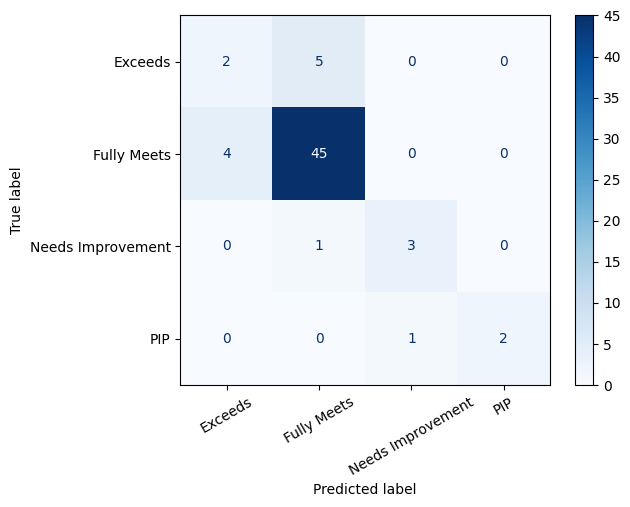

In [35]:
# apply best hyperparameter
gb_best = gb_grid_search.best_estimator_

# fit di train
gb_best.fit(x_train, y_train)

# predict test
y_pred = gb_best.predict(x_test)

# classification report
print(classification_report(y_test, y_pred))

# confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=gb_best.classes_)

display_cm = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=gb_best.classes_)
display_cm.plot(cmap='Blues', xticks_rotation=30)
plt.show()

The final test result is encouraging. Overall accuracy reaches **0.83**, while the macro-average scores remain respectable at **0.74 precision**, **0.66 recall**, and **0.69 F1-score**. More importantly, the model is not relying only on the majority class. `Needs Improvement` is captured with balanced precision and recall, and `PIP` shows very strong precision with moderate recall, which means the model can already identify the most critical low-performance cases with useful reliability despite very limited support.

The strongest class remains `Fully Meets`, which is expected given its much larger presence in the dataset. The weakest result appears in `Exceeds`, where several employees are still absorbed into `Fully Meets`. That confusion is understandable because the boundary between strong and very strong performance is likely narrower than the boundary between acceptable and problematic performance.

Overall, the tuned model is more useful as an early warning and support tool for lower-performance detection than as a precise separator of top performers. That fits the original business priority well.

---
# **Conclusion**
---

## **Model Summary**

This modeling stage shows that employee performance can be predicted with a reasonably useful level of accuracy, but the results also confirm that the target is not evenly easy to separate across all classes. The strongest class pattern remains concentrated in `Fully Meets`, while the smaller classes require more careful treatment through preprocessing design, imbalance handling, and model evaluation. 

This makes the modeling task less about finding a single high score and more about building a workflow that remains stable, interpretable, and suitable for HR use.

Among the baseline models, Gradient Boosting produced the strongest overall result and remained the best candidate after tuning. The final pipeline also benefited from several preprocessing revisions, especially the use of `SMOTENC` before final categorical encoding, the treatment of `EmploymentStatus` as a nominal feature, and the use of `StandardScaler`, which performed better than `RobustScaler` in the final comparison.

On the test set, the tuned model performed strongly on `Fully Meets`, while `Needs Improvement` and `PIP` were still captured at an acceptable level despite their limited class sizes.

1. **Gradient Boosting produced the strongest overall performance.**  
   Compared with the other baseline models, Gradient Boosting gave the most balanced result and remained the strongest option after hyperparameter tuning. This suggests that employee performance is better captured through a gradual ensemble learning process than through simpler decision boundaries alone.

2. **The preprocessing design had a direct effect on model quality.**  
   The final pipeline improved after the feature flow was revised more carefully. `SMOTENC` was placed before final categorical encoding, `EmploymentStatus` was treated as a nominal feature, and `StandardScaler` produced better baseline results than `RobustScaler`. These steps helped create a more reliable training structure before tuning even began.

3. **The final model is strongest on the majority class, but still useful on lower-performing groups.**  
   `Fully Meets` was classified very well, which is expected given its larger representation in the dataset. At the same time, `Needs Improvement` and `PIP` were still identified with reasonably good results, showing that the model can detect lower-performing employees better than a majority-class-only pattern would suggest.

4. **Class separation is still uneven, especially for `Exceeds`.**  
   The weakest results appear in the `Exceeds` class, which is often confused with `Fully Meets`. This suggests that the model has more difficulty distinguishing strong performance from very strong performance than it does distinguishing the lower end of the scale.

5. **The model is useful as a support tool, not as a standalone decision-maker.**  
   The final result is strong enough to support early screening and structured review, but it should not be used as an automatic judgment system. In an HR setting, model predictions still need to be interpreted together with qualitative review, manager input, and recent employee context.

## **Business Recommendation**

1. **Use the model as an early warning tool for lower-performing employees.**  
   The model is most valuable when it helps flag employees who may require earlier support, especially those predicted as `Needs Improvement` or `PIP`. This gives HR and managers a chance to respond before performance issues become more difficult to address.

2. **Combine model predictions with human review before taking action.**  
   A prediction should function as a signal for closer evaluation rather than a final label. Manager feedback, recent work context, and individual circumstances should still be reviewed to avoid overly mechanical decisions.

3. **Focus improvement strategies on the behavioral signals that showed stronger separation.**  
   Variables such as lateness, engagement, and satisfaction showed clearer relationships with performance outcomes during the earlier analysis. These areas can be used to guide follow-up actions such as coaching, attendance support, workload review, or employee engagement intervention.

4. **Treat weaker classes with more caution during interpretation.**  
   The model is less stable in separating `Exceeds` from `Fully Meets`, so predictions at the upper end of performance should be interpreted more carefully. In practice, the model is currently more dependable for detecting possible risk than for distinguishing fine-grained differences among stronger performers.

## **Further Improvements**

1. **Increase support for minority classes.**  
   Some performance groups, especially `Needs Improvement` and `PIP`, still have very limited observations. Additional data would help the model learn those patterns more consistently and reduce the instability that comes from very small class sizes.

2. **Expand feature coverage with more performance-related signals.**  
   The current model is built from the available employee and workplace variables, but future improvement may come from richer job context, manager-related factors, or more detailed behavioral indicators that are still relevant and appropriate for HR use.

3. **Compare additional ensemble models and calibration strategies.**  
   Gradient Boosting already performed well, but future iterations can still test alternative boosting approaches or probability calibration methods to improve separation quality, especially for the smaller classes.

4. **Evaluate the model through operational monitoring after deployment.**  
   Once used in practice, model performance should continue to be monitored to see whether prediction quality remains stable over time. This is important because employee behavior, workplace conditions, and class distribution may shift as new data is collected.

---
# **Model Saving**
---

In [36]:
# save x_train num_columns
with open('model_saving\list_num_cols.txt', 'w') as file_1:
  json.dump(num_columns, file_1)

# save x_train cat_columns
with open('model_saving\list_cat_cols.txt', 'w') as file_2:
  json.dump(cat_columns, file_2)

# save best model
joblib.dump(gb_best, 'model_saving\gb_best_model.pkl')

['model_saving\\gb_best_model.pkl']

---
# **Model Inference Test**
---

The inference process is tested in a separate notebook, [model-inference.ipynb](model-inference.ipynb).

Keeping inference separate helps verify that the saved preprocessing metadata and the trained model can be reused consistently outside the training workflow.

---
# **Model Deployment**
---

To demonstrate the final model in use, a simple inference application was deployed on [**Hugging Face**](https://huggingface.co/spaces/seankafka/Performance-Prediction).

This demo allows users to input employee-related features and observe the predicted `PerformanceScore` outcome through an interactive interface.